# 📘 Домашнє завдання №16. Прогнозування часових рядів

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW16


# 📊 Дані

## 1. Датасет для ARIMA (без сезонності)

```python
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200
time = np.arange(n)

trend = 0.1 * time
noise = np.random.normal(0, 1, n)

values = trend + noise

dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

df_arima = pd.DataFrame({
    'ds': dates,
    'y': values
})
```

---

## 2. Датасет для SARIMA / ML / Prophet (із сезонністю)

```python
np.random.seed(42)

n = 240
time = np.arange(n)

trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)

values = trend + seasonality + noise

dates = pd.date_range(start='2015-01-01', periods=n, freq='M')

df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values
})
```


# 🧠 Завдання

## 🔹 Завдання 1. Аналіз і візуалізація

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

---

## 🔹 Завдання 2. Побудова моделей

### 📌 2.1 ARIMA (для df_arima)

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

---

### 📌 2.2 SARIMA (для df_seasonal)

1. Визначити сезонність (період m)
2. Використати auto_arima (з seasonal=True)
3. Натренувати модель
4. Побудувати прогноз

---

### 📌 2.3 Prophet (для df_seasonal)

1. Переконатися, що дані мають формат:

   * ds — дата
   * y — значення

2. Натренувати модель:

```python
from prophet import Prophet

model = Prophet()
model.fit(df_seasonal)
```

3. Створити майбутні дати:

```python
future = model.make_future_dataframe(periods=24, freq='M')
```

4. Побудувати прогноз:

```python
forecast = model.predict(future)
```

5. Побудувати графіки:

* прогнозу
* компонентів (trend, seasonality)

---

### 📌 2.4 ML модель (для df_seasonal)

Обрати одну модель:

* XGBoost / RandomForest / CatBoost

1. Створити фічі:

   * lag_1, lag_2, lag_12
   * rolling статистики
   * календарні фічі (місяць, рік)

2. Розбити дані на train/test

3. Натренувати модель

4. Побудувати прогноз

---

## 🔹 Завдання 3. Візуальна оцінка

Для кожної моделі:

1. Побудувати графік:

   * train
   * test
   * forecast

2. Оцінити:

   * чи модель ловить тренд
   * чи модель ловить сезонність
   * чи є систематичні помилки

---

## 🔹 Завдання 4. Оцінка якості

Для кожної моделі обчислити:

* MAE
* RMSE
* MAPE

Порівняти:

* ARIMA (manual vs auto)
* SARIMA vs Prophet
* Prophet vs ML


In [1]:
# TODO: uncommit
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "pandas",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "pmdarima",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# TODO: uncommit
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
# hm_version = 16
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [3]:
# Data synthesis - Датасет для ARIMA

import numpy as np
import pandas as pd
from IPython.display import display
from fontTools.diff import color

# Input data
rng_seed = 42
n = 200
pd.options.display.float_format = "{:g}".format

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.1 * time
noise = np.random.normal(0, 1, n)
values = trend + noise
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

# створюємо DataFrame
ds_arima_name = "ARIMA (без сезонності)"
df_arima = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_arima)

,ds,y
0,2020-01-01,0.496714
1,2020-01-02,-0.0382643
2,2020-01-03,0.847689
3,2020-01-04,1.82303
4,2020-01-05,0.165847
...,...,...
195,2020-07-14,19.8853
196,2020-07-15,18.7161
197,2020-07-16,19.8537
198,2020-07-17,19.8582


In [4]:
# Data synthesis - Датасет для SARIMA

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
n = 240

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)
values = trend + seasonality + noise
dates = pd.date_range(start='2015-01-01', periods=n, freq='MS')  # початок кожного місяця

# створюємо DataFrame
ds_seasonal_name = "SARIMA / ML / Prophet (із сезонністю)"
df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_seasonal)

,ds,y
0,2015-01-01,0.993428
1,2015-02-01,4.77347
2,2015-03-01,10.0556
3,2015-04-01,13.1961
4,2015-05-01,8.39195
...,...,...
235,2034-08-01,8.01784
236,2034-09-01,-0.910539
237,2034-10-01,2.22291
238,2034-11-01,1.91617


## ✅ Рішення 1

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

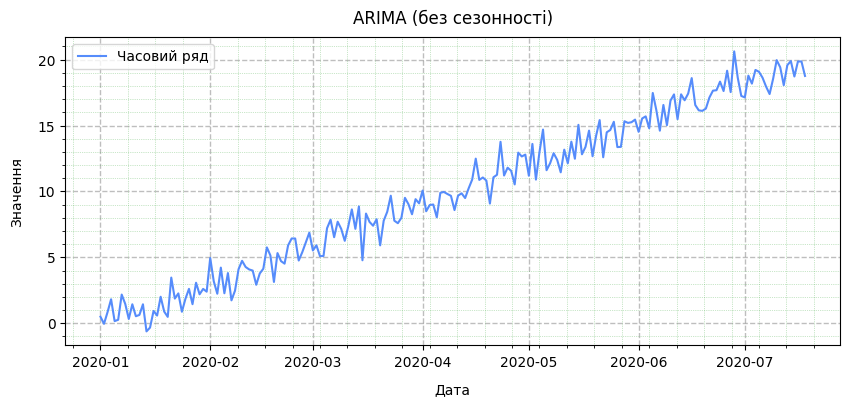

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_arima

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

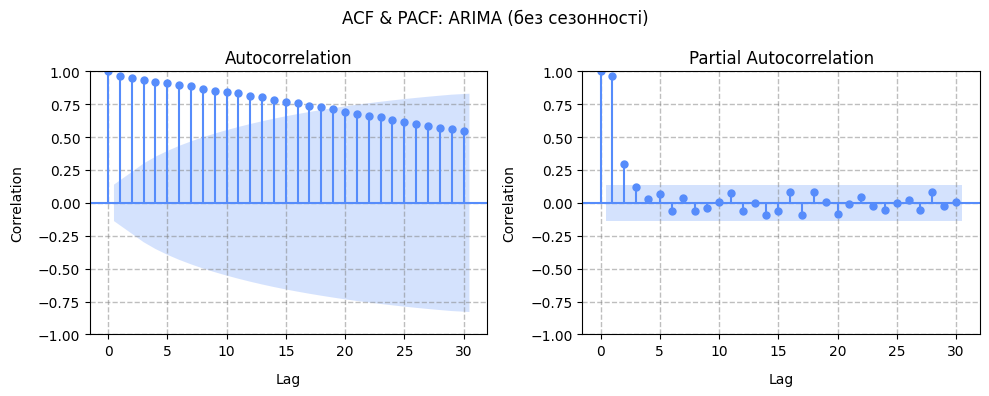

In [6]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_arima["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

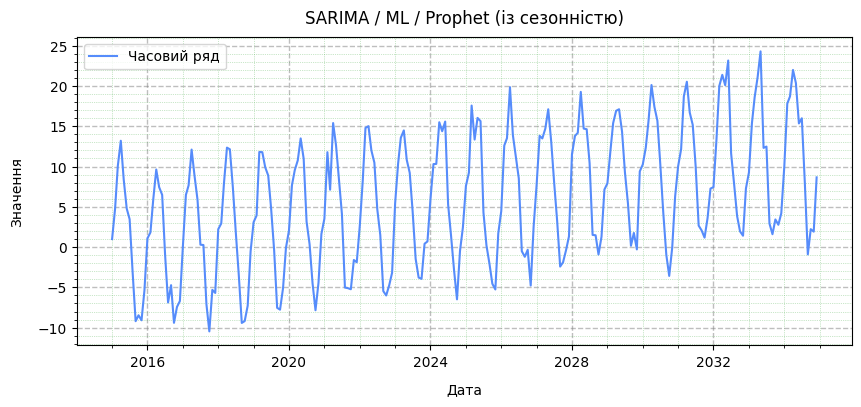

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_seasonal

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_seasonal_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

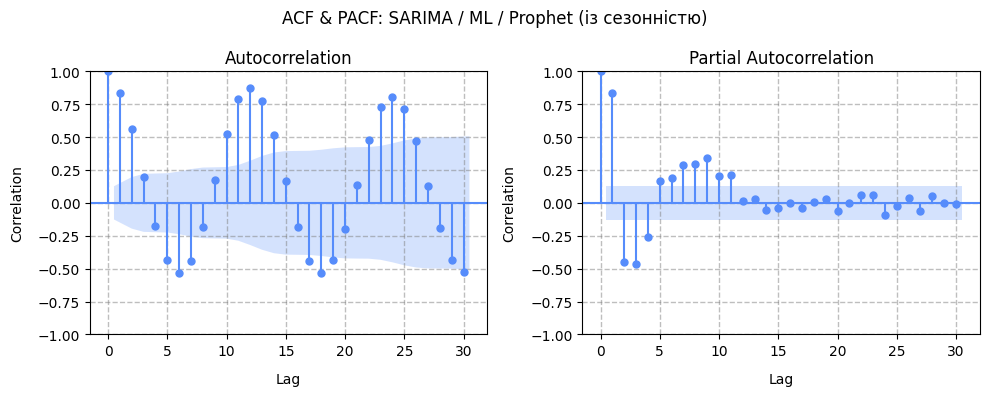

In [8]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_seasonal["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

* **ACF** — (автокореляція) відображає прямий і непрямий звʼязок із лагами.
* **PACF** — (часткова кореляція) відображає тільки прямий звʼязок із лагами.

Параметр    | графік ACF                 | графік PACF
------------|----------------------------|------------
AR(p)       | Затихає плавно             | Обривається різко на p лагу
MA(q)       | Обривається різко на q лагу | Затихає плавно

- **d** — кількість диференціювань до досягнення стаціонарності ряду.
- **p** — індекс лагу, на якому обірвався **PACF** графік на стаціонарному ряді.
- **q** — індекс лагу, на якому обірвався **ACF** графік на стаціонарному ряді.

Висновок. Датасет для ARIMA — за графіком ACF згасає плавно, а отже, це авторегресія і немає стаціонарності, і є тренд. Датасет для SARIMA —— за графіком ACF має гармонічну форму з повільним, плавним згасанням, а отже, він немає стаціонарності, а має тренд і сезонність, а період сезонності можна визначити за кількістю лагів між піками.

## ✅ Рішення 2.1

Для обох датасетів:

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

In [9]:
import numpy as np
import apps.main as mn
import apps.reporter as rpt
from IPython.core.display import Markdown
from statsmodels.tsa.stattools import adfuller

# Input data

# Solution
d_ar = 0
p_value_ar = adfuller(df_arima["y"])[1]  # type: ignore
stat_ar = mn.is_stationary(p_value_ar)

rp_ar = rpt.Reporter()
rp_ar.tolerance = 4
rp_ar.add_item("Стаціонарність початкових даних", 'так' if stat_ar else 'ні')
if p_value_ar < np.power(10.0, -rp_ar.tolerance):
    rp_ar.add_item("Початкове p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
else:
    rp_ar.add_item("Початкове p-value", rp_ar.format_value(p_value_ar))

if not stat_ar:
    stat_ar, d_ar, p_value_ar, output_ar = mn.find_stationarity(df_arima["y"].values)

    rp_ar.add_item("Досягнуто стаціонарності", 'так' if stat_ar else 'ні')
    if p_value_ar < np.power(10.0, -rp_ar.tolerance):
        rp_ar.add_item("Отримане p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
    else:
        rp_ar.add_item("Отримане p-value", rp_ar.format_value(p_value_ar))

rp_ar.add_item("Параметр інтегрованості, d", str(d_ar))

d_s = 0
p_value_s = adfuller(df_seasonal["y"])[1]  # type: ignore
stat_s = mn.is_stationary(p_value_s)

rp_s = rpt.Reporter()
rp_s.tolerance = 4
rp_s.add_item("Стаціонарність початкових даних", 'так' if stat_s else 'ні')
if p_value_s < np.power(10.0, -rp_s.tolerance):
    rp_s.add_item("Початкове p-value", f"{p_value_s:.{rp_s.tolerance}e}")
else:
    rp_s.add_item("Початкове p-value", rp_s.format_value(p_value_s))

if not stat_s:
    stat_s, d_s, p_value_s, output_s = mn.find_stationarity(df_seasonal["y"].values)

    rp_s.add_item("Досягнуто стаціонарності", 'так' if stat_s else 'ні')
    if p_value_s < np.power(10.0, -rp_s.tolerance):
        rp_s.add_item("Отримане p-value", f"{p_value_s:.{rp_s.tolerance}e}")
    else:
        rp_s.add_item("Отримане p-value", rp_s.format_value(p_value_s))

rp_s.add_item("Параметр інтегрованості, d", str(d_s))

# Print results
display(Markdown(f"### {ds_arima_name}"))
rp_ar.print_pd_report()
display(Markdown(f"### {ds_seasonal_name}"))
rp_s.print_pd_report()


### ARIMA (без сезонності)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9525
Досягнуто стаціонарності,так
Отримане p-value,1.6789e-11
"Параметр інтегрованості, d",1


### SARIMA / ML / Prophet (із сезонністю)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9387
Досягнуто стаціонарності,так
Отримане p-value,2.6649e-22
"Параметр інтегрованості, d",1


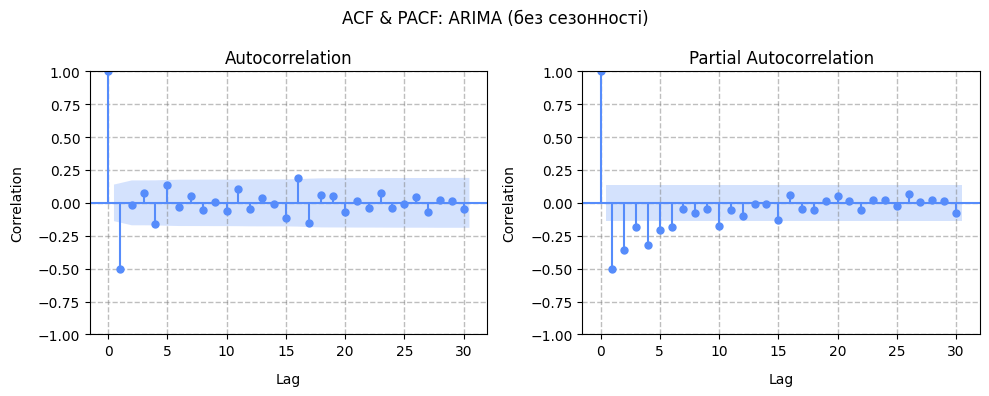

In [10]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_ar

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

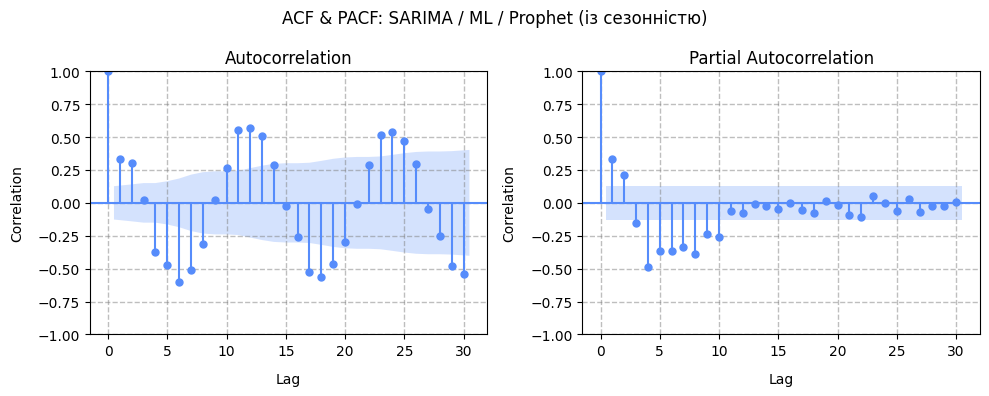

In [11]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_s

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

Висновок. За допомогою диференціювання було видалено тренди, але тест Дікі-Фуллера не виявляє сезонність і не забезпечує повної стаціонарності.

In [12]:
import apps.main as mn
import apps.reporter as rpt

# Input data
data_set = output_ar

# Solution

# знаходження q вручну
q_ar = mn.find_q_acf_manually(data_set)
p_ar = mn.find_p_pacf_manually(data_set)

rp = rpt.Reporter()
rp.add_item("Авторегресійний параметр, p", str(p_ar))
rp.add_item("Інтегрованості параметр, d", str(d_ar))
rp.add_item(f"Ковзного середнього параметр, q", str(q_ar))
rp.add_item("Структура ARIMA: (p, d, q)", f"({p_ar}, {d_ar}, {q_ar})")

# Print results
rp.print_pd_report(ds_arima_name)

Attribute,Result
"Авторегресійний параметр, p",6
"Інтегрованості параметр, d",1
"Ковзного середнього параметр, q",1
"Структура ARIMA: (p, d, q)","(6, 1, 1)"


Примітка. У цьому випадку параметр "p" був обраний автоматично й дуже суворо, а оскільки PACF показує плавне згасання, то це ознака ковзного середнього й у такому випадку обирається p = 0.

In [13]:
# Splitting data

import apps.main as mn
from IPython.display import display

# Input data
test_ratio = 0.2

# Solution
Y_train_ar, Y_test_ar = mn.train_test_split_by_order(df_arima, test_size=test_ratio)

# Print results
display(df_arima["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для всього часового ряду"))
display(Y_train_ar["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тренувальної вибірки"))
display(Y_test_ar["y"].to_frame().describe().T.style.format("{:g}").set_caption("Статистика для тестової вибірки"))

,count,mean,std,min,25%,50%,75%,max
y,200,9.90923,5.92743,-0.61328,4.77539,9.74223,15.0867,20.6202


,count,mean,std,min,25%,50%,75%,max
y,160,7.8824,4.78374,-0.61328,3.95139,7.945,11.8846,17.4658


,count,mean,std,min,25%,50%,75%,max
y,40,18.0166,1.30813,15.0253,17.2144,18.0037,18.8552,20.6202


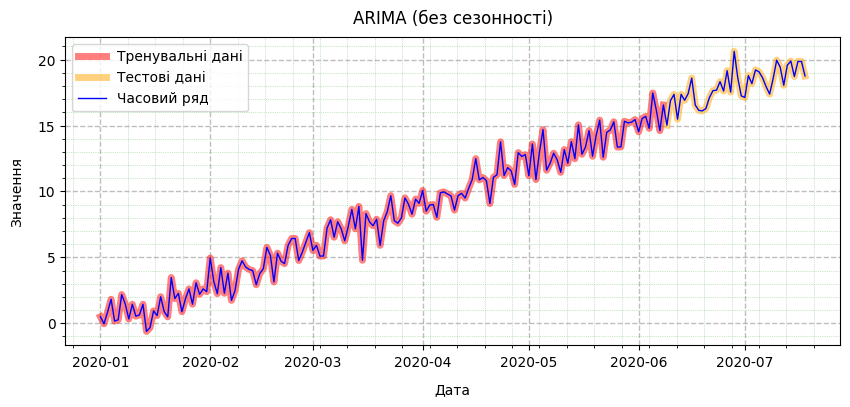

In [14]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_ar["ds"], Y_train_ar["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_ar["ds"], Y_test_ar["y"], linewidth=5.0, alpha=0.5, color="orange", label="Тестові дані")
ax.plot(df_arima["ds"], df_arima["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

In [15]:
import joblib
import apps.reporter as rpt
from pmdarima import auto_arima
from pathlib import Path

# Input data
load_model = True
model_file_name = "resources/auto_arima_search_parameters.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = auto_arima(
        Y_train_ar["y"],
        seasonal=False,  # без сезонності
        stepwise=True,  # алгоритм пошуку Бокса — Дженкінса, швидше ніж перебір (Grid Search)
        # n_jobs=-1, # використовувати коли  stepwise=False
    )
    # save model
    joblib.dump(model, model_file_name)

rp = rpt.Reporter()
rp.add_item("Авторегресійний параметр, p", str(model.order[0]))
rp.add_item("Інтегрованості параметр, d", str(model.order[1]))
rp.add_item(f"Ковзного середнього параметр, q", str(model.order[2]))
rp.add_item("Структура ARIMA: (p, d, q)", str(model.order))

# Print results
display(Markdown(f"### {ds_arima_name}"))
rp.print_pd_report("Автоматично підібрані параметри")
print(model.summary())

### ARIMA (без сезонності)

Attribute,Result
"Авторегресійний параметр, p",5
"Інтегрованості параметр, d",1
"Ковзного середнього параметр, q",0
"Структура ARIMA: (p, d, q)","(5, 1, 0)"


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:               SARIMAX(5, 1, 0)   Log Likelihood                -224.489
Date:                Sat, 16 May 2026   AIC                            462.978
Time:                        10:24:04   BIC                            484.460
Sample:                             0   HQIC                           471.702
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3961      0.093      4.275      0.000       0.214       0.578
ar.L1         -0.9195      0.094     -9.794      0.000      -1.104      -0.736
ar.L2         -0.7850      0.124     -6.343      0.0

In [16]:
import apps.main as mn
from statsmodels.tsa.arima.model import ARIMA

# Input data
n_periods_ar = len(Y_test_ar)

# Solution
Y_pred_ar = model.predict(n_periods=n_periods_ar)

model_check = ARIMA(Y_train_ar["y"], order=model.order, trend='t')
model_fit = model_check.fit()
Y_pred_ar_check = model_fit.forecast(steps=n_periods_ar)

# Print results
display(Markdown(f"**Оцінка за: auto_arima(...)**"))
_ = mn.calc_regres_metrics(Y_test_ar["y"], Y_pred_ar)
display(Markdown(f"**Оцінка за: ARIMA(...)**"))
_ = mn.calc_regres_metrics(Y_test_ar["y"], Y_pred_ar_check)

**Оцінка за: auto_arima(...)**

Attribute,Result
MAE,0.6920
MSE,0.7662
RMSE,0.8753
R² (коефіцієнт детермінації),0.5408
MAPE,0.0387


**Оцінка за: ARIMA(...)**

Attribute,Result
MAE,0.6920
MSE,0.7661
RMSE,0.8753
R² (коефіцієнт детермінації),0.5408
MAPE,0.0387


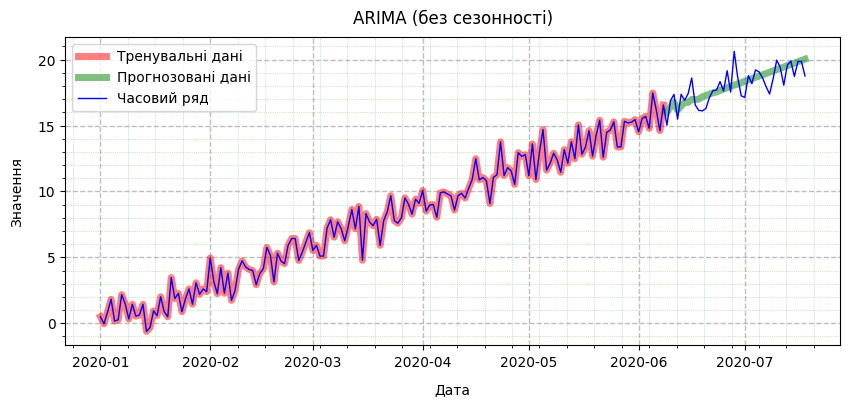

In [17]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(Y_train_ar["ds"], Y_train_ar["y"], linewidth=5.0, alpha=0.5, color="red", label="Тренувальні дані")
ax.plot(Y_test_ar["ds"], Y_pred_ar, linewidth=5.0, alpha=0.5, color="green", label="Прогнозовані дані")
ax.plot(df_arima["ds"], df_arima["y"], linewidth=1.0, color="blue", label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

Примітка. Порівнюючи на даному кроці вручну визначенні параметри й параметри, які були отримані автоматично через модель ARIMA, виявляється, що результати доволі близькі, за винятком пропозиції застосувати p = 0 для ознаки ковзного середнього.

Висновок. Прогноз даної моделі більше схожий на прогноз тренду, ніж на повноцінний прогноз.

## ✅ Рішення 2.2

1. Визначити сезонність (період m)
2. Використати auto_arima (з seasonal=True)
3. Натренувати модель
4. Побудувати прогноз

index_phase 20
frequency 0.08333333333333333
lag 12.0


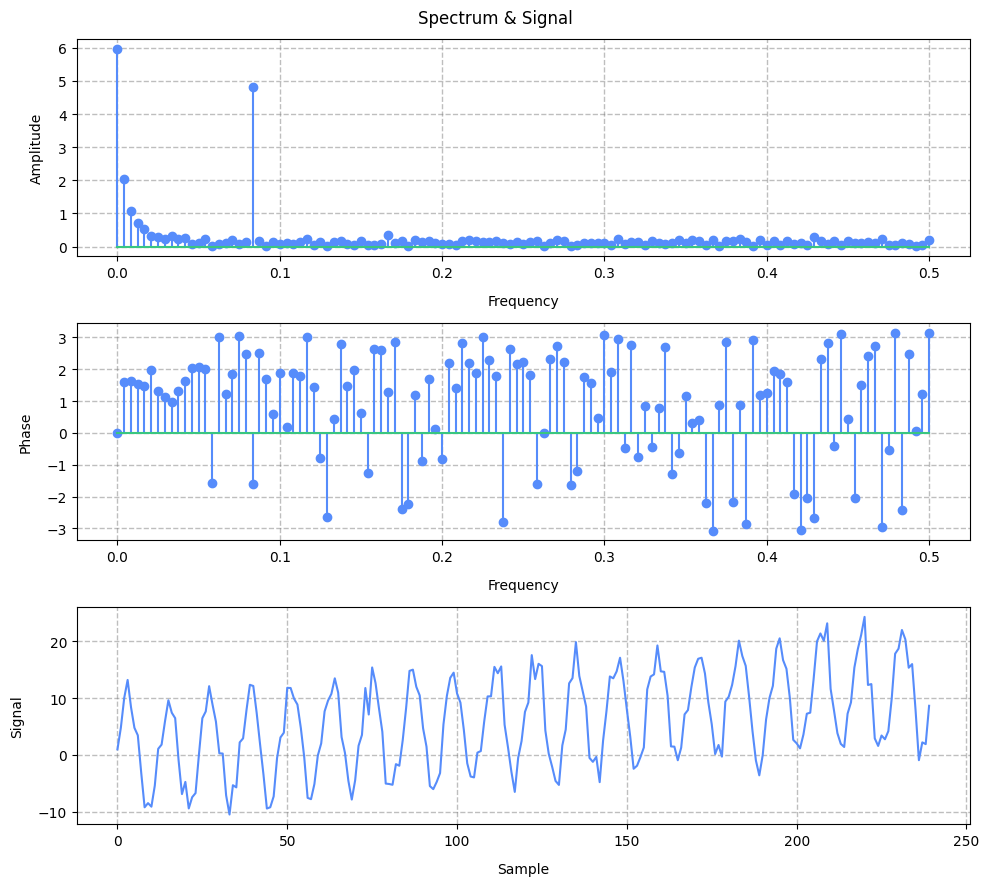

In [18]:
# Аналіз наявності сезонності

import numpy as np
import apps.fourier as fr
from scipy.fft import rfft, irfft, rfftfreq

# Input data
save_size = 0.17
save_level = 0.5
temp_df = df_seasonal.copy()
temp_df["id"] = temp_df.index
original_array = temp_df["y"].to_numpy()

# Solution
n_array = len(original_array)
spectrum = rfft(original_array)
n_spectrum = len(spectrum)
amplitudes = np.asarray(np.abs(spectrum) / n_array)
phases = np.asarray(np.angle(spectrum))
frequencies = rfftfreq(n_array)

max_amplitude = np.max(np.abs(amplitudes))
drop_amplitude = max_amplitude * save_level

n_save = int(n_spectrum * save_size)

changed_amplitudes = []
changed_phases = []

for idx in range(n_spectrum):
    amplitude = amplitudes[idx]
    phase = phases[idx]

    if idx > n_save:
        amplitude = 0.0
        phase = 0.0

    if np.abs(amplitude) < drop_amplitude:
        amplitude = 0.0
        phase = 0.0

    changed_amplitudes.append(amplitude)
    changed_phases.append(phase)

changed_amplitudes = np.asarray(changed_amplitudes)
changed_phases = np.asarray(changed_phases)

recovered_spectrum = changed_amplitudes * np.exp(1j * changed_phases) * n_array
recovered_array = irfft(recovered_spectrum, n=n_array)

index_phase = np.argmax(np.abs(changed_phases))
print("index_phase", index_phase)
frequency = frequencies[index_phase]
print("frequency", frequency)
lag = 1 / frequency
print("lag", lag)

fr.plot_signal_spectrum(original_array, figsize=(10, 9))

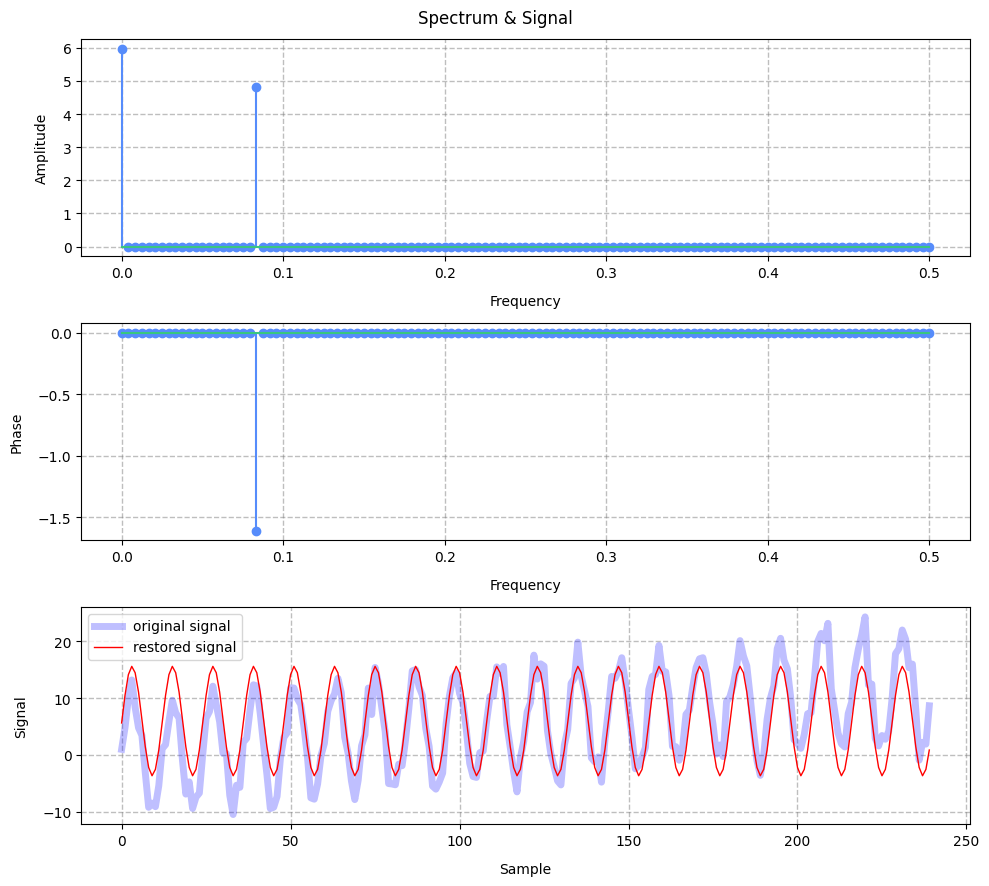

In [19]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, axes = plt.subplots(3, 1, figsize=(10, 9))

# Amplitude
ax = axes[0]
# ax.stem(frequencies, amplitudes)
ax.stem(frequencies, changed_amplitudes)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_ylabel(f"Amplitude", labelpad=10, loc='center', color='black')
# Frequency
ax.set_xlabel("Frequency", labelpad=10, loc='center', color='black')

# Phase
ax = axes[1]
# ax.stem(frequencies, phases)
ax.stem(frequencies, changed_phases)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_ylabel(f"Phase", labelpad=10, loc='center', color='black')
# Frequency
ax.set_xlabel("Frequency", labelpad=10, loc='center', color='black')

# Signal
ax = axes[2]
ax.plot(original_array, color="blue", linewidth=5.0, alpha=0.25, label="original signal")
ax.plot(recovered_array, color="red", linewidth=1.0, label="restored signal")
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_ylabel(f"Signal", labelpad=10, loc='center', color='black')
ax.set_xlabel("Sample", labelpad=10, loc='center', color='black')
ax.legend()

plt.suptitle(f"Spectrum & Signal")

plt.tight_layout()
plt.show()